In [1]:
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import numpy as np
import sys

In [2]:
def create_grayscale_circle(size=128, radius=50, tol=1e-3):
    """
    Creates a grayscale image of a circle.

    Args:
        size (int): The width and height of the square image.
        radius (int): The radius of the circle.

    Returns:
        numpy.ndarray: A 2D NumPy array representing the grayscale image.
    """
    # Create a white 2D array for the image
    image_array = np.ones((size, size), dtype=np.uint8) * 255

    # Calculate the center of the image
    center = size // 2

    # Iterate over each pixel and check if it's within the circle's radius
    for y in range(size):
        for x in range(size):
            # Calculate the distance from the center
            distance = np.sqrt((x - center) ** 2 + (y - center) ** 2)
            
            # If the distance is less than or equal to the radius, make the pixel white
            if np.isclose(distance, radius, atol=tol):
                image_array[y, x] = 0  # 0 for black in a grayscale image

    return image_array

(9, 9)

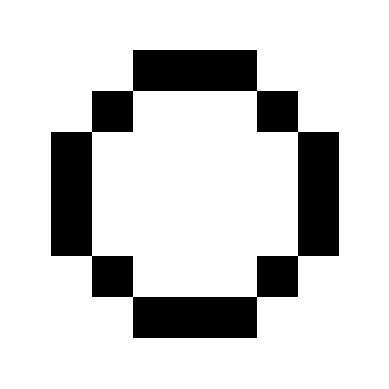

In [3]:
image = create_grayscale_circle(size=9, radius=3, tol=5e-1) # RGB image
plt.imshow(image, cmap="gray")
plt.axis("off")
image.shape
#plt.savefig("coins.png")

In [4]:
def gaussian_kernel(size=7, sigma=1.0):
    """
    Creates a 2D Gaussian kernel.

    size : int (must be odd) -> dimension of the kernel (size x size)
    sigma: float -> standard deviation of the Gaussian
    """
    # Make a coordinate grid centered at 0
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel = kernel / np.sum(kernel)  # normalize
    return kernel

kernel = gaussian_kernel(size=7, sigma=2.5)

(9, 9)

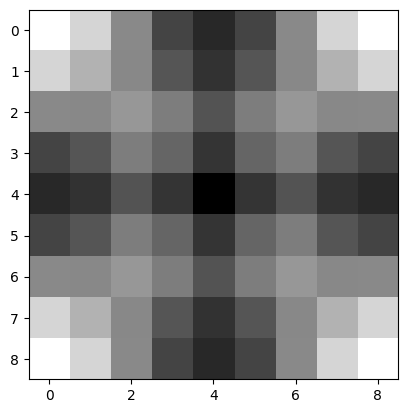

In [5]:
blurred = convolve2d(image, kernel, mode="same", boundary="symm")
plt.imshow(blurred, cmap="gray")
blurred.shape

In [6]:
def build_conv_matrix(psf, image_shape, boundary='zero'):
    """
    Build the convolution matrix A for a convolution with `psf`
    acting on images of shape `image_shape` (h, w).
    Convolution is linear, using zero outside the image by default.
    Returns A as an (N, N) numpy array where N = h*w.
    The mapping is: vec(convolve2d(image, psf, mode='same')) = A @ vec(image)
    """
    h, w = image_shape
    N = h * w
    A = np.zeros((N, N), dtype=np.float64)

    # helper: convolve single-pixel image (unit impulse at (r,c))
    def conv_unit(r, c):
        img = np.zeros(image_shape, dtype=np.float64)
        img[r, c] = 1.0
        # mode='same' produces output same size; boundary handling:
        if boundary == 'zero':
            return convolve2d(img, psf, mode='same', boundary='fill', fillvalue=0.0)
        elif boundary == 'symm':
            return convolve2d(img, psf, mode='same', boundary='symm')
        else:
            raise ValueError("unsupported boundary: choose 'zero' or 'symm'")

    # Build columns of A: effect of basis vector e_j (unit pixel at j)
    col = 0
    for r in range(h):
        for c in range(w):
            conv_result = conv_unit(r, c)
            A[:, col] = conv_result.ravel()
            col += 1

    return A

A = build_conv_matrix(kernel, image.shape, boundary="symm")

In [7]:
# Memory
A_bytes = sys.getsizeof(A)
print("A takes", A_bytes / 1024 / 1024, "Mbs")

A takes 0.05017852783203125 Mbs


In [8]:
def find_solution(x: np.ndarray, b: np.ndarray, A: np.ndarray, noise: float=0):   
    # Vectorize
    x_true = x.copy().ravel()
    _b = b.copy().ravel()

    # add error
    rng = np.random.default_rng(0)
    noise_v = rng.standard_normal(_b.shape) * noise
    _b += noise_v

    # Try direct inverse if A is invertible
    try:
        Ainv = np.linalg.inv(A)
        x_rec_v = Ainv @ _b
        print("\nConstructed direct inverse\n")

    except np.linalg.LinAlgError:
        Ainv = np.linalg.pinv(A)
        x_rec_v = Ainv @ _b
        print("\nConstructed pseudo-inverse\n")

    deblurred = x_rec_v.reshape(image.shape)

    # Check reconstruction error
    err = np.linalg.norm(x_rec_v - x_true) / np.linalg.norm(x_true)
    print(f"Relative reconstruction error: {err:.3e}")

    return deblurred



Constructed direct inverse

Relative reconstruction error: 5.244e-13


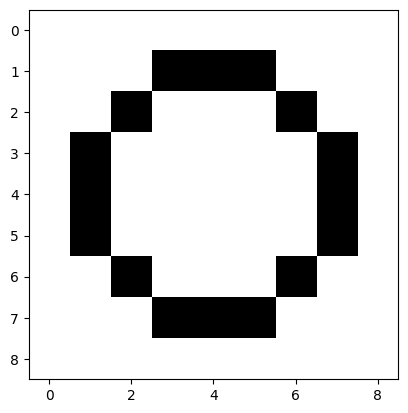

In [9]:
noiseless_solution = find_solution(image, blurred, A)
plt.imshow(noiseless_solution, cmap="gray")


Constructed direct inverse

Relative reconstruction error: 2.131e-01


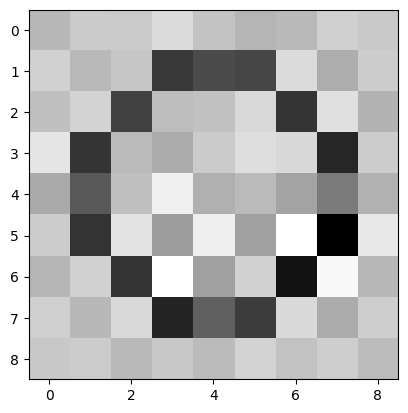

In [13]:
noisy_solution = find_solution(image, blurred, A, noise=1e-1)
plt.imshow(noisy_solution, cmap="gray")